In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from pathlib import Path

from sklearn.ensemble import (
    RandomForestRegressor,
    RandomForestClassifier,
    GradientBoostingClassifier,
    HistGradientBoostingClassifier
)
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve
)
from imblearn.combine import SMOTETomek
import lightgbm as lgb
from xgboost import XGBClassifier

# =========================
# 0. 基础设置
# =========================
BASE_DIR = Path(".")
SAMPLE_PATH = BASE_DIR / "sample.csv"

if not SAMPLE_PATH.exists():
    raise FileNotFoundError("当前目录下没有 sample.csv，请先把 sample.csv 放到 notebook 同目录。")

RANDOM_STATE = 42
TEST_SIZE = 0.30

FINAL_COLS = [
    'user_id', 'y',
    'x_001', 'x_002', 'x_003', 'x_004', 'x_005', 'x_006',
    'x_019', 'x_020', 'x_021', 'x_027',
    'x_033', 'x_034', 'x_035', 'x_036', 'x_037', 'x_038',
    'x_041', 'x_042', 'x_044', 'x_045',
    'x_048', 'x_049', 'x_052', 'x_054', 'x_055', 'x_056',
    'x_074', 'x_075', 'x_077', 'x_078',
    'x_088', 'x_089',
    'x_121', 'x_122', 'x_124', 'x_125',
    'x_131', 'x_132', 'x_134', 'x_137',
    'x_142', 'x_143', 'x_144',
    'x_149', 'x_154', 'x_155', 'x_157', 'x_159', 'x_162',
    'x_188', 'x_189', 'x_190', 'x_196', 'x_197', 'x_198'
]

BIN_COLS = [
    'x_002', 'x_020', 'x_021', 'x_027', 'x_033', 'x_034', 'x_035', 'x_036', 'x_037', 'x_038',
    'x_041', 'x_042', 'x_044', 'x_045', 'x_048', 'x_049', 'x_052', 'x_054', 'x_055', 'x_056',
    'x_074', 'x_075', 'x_077', 'x_078', 'x_088', 'x_089', 'x_121', 'x_122', 'x_124', 'x_125',
    'x_131', 'x_132', 'x_134', 'x_137', 'x_142', 'x_143', 'x_144', 'x_149', 'x_154', 'x_155',
    'x_157', 'x_159', 'x_162', 'x_188', 'x_189', 'x_190', 'x_196', 'x_197', 'x_198'
]

# =========================
# 1. 工具函数
# =========================
def replace_inf_with_nan(df):
    return df.replace([np.inf, -np.inf], np.nan)

def fill_numeric_na(df, reference_df=None):
    df = df.copy()
    num_cols = df.select_dtypes(include=[np.number]).columns.tolist()

    if reference_df is None:
        reference_df = df

    for col in num_cols:
        med = reference_df[col].median()
        if pd.isna(med):
            med = 0.0
        df[col] = df[col].replace([np.inf, -np.inf], np.nan).fillna(med)

    return df

def calculate_ks(y_true, y_pred_proba):
    fpr, tpr, _ = roc_curve(y_true, y_pred_proba)
    return float(np.max(np.abs(tpr - fpr)))

def calculate_psi(train_scores, test_scores, bins=10):
    train_scores = np.asarray(train_scores, dtype=float)
    test_scores = np.asarray(test_scores, dtype=float)

    train_scores = np.where(np.isfinite(train_scores), train_scores, np.nan)
    test_scores = np.where(np.isfinite(test_scores), test_scores, np.nan)

    train_scores = pd.Series(train_scores).fillna(pd.Series(train_scores).median()).values
    test_scores = pd.Series(test_scores).fillna(pd.Series(train_scores).median()).values

    quantiles = np.linspace(0, 1, bins + 1)
    edges = np.quantile(train_scores, quantiles)
    edges = np.unique(edges)

    if len(edges) < 3:
        return 0.0

    train_bin = pd.cut(train_scores, bins=edges, include_lowest=True)
    test_bin = pd.cut(test_scores, bins=edges, include_lowest=True)

    categories = train_bin.categories
    train_counts = pd.Series(train_bin).value_counts().reindex(categories, fill_value=0).values
    test_counts = pd.Series(test_bin).value_counts().reindex(categories, fill_value=0).values

    train_ratio = (train_counts + 1e-6) / (train_counts.sum() + 1e-6)
    test_ratio = (test_counts + 1e-6) / (test_counts.sum() + 1e-6)

    psi = np.sum((test_ratio - train_ratio) * np.log(test_ratio / train_ratio))
    return float(psi)

def evaluate_model(model, x_train_eval, y_train_eval, x_test_eval, y_test_eval, model_name):
    train_prob = model.predict_proba(x_train_eval)[:, 1]
    test_pred = model.predict(x_test_eval)
    test_prob = model.predict_proba(x_test_eval)[:, 1]

    result = {
        "model": model_name,
        "Accuracy": accuracy_score(y_test_eval, test_pred),
        "Precision": precision_score(y_test_eval, test_pred, zero_division=0),
        "Recall": recall_score(y_test_eval, test_pred, zero_division=0),
        "F1": f1_score(y_test_eval, test_pred, zero_division=0),
        "AUC": roc_auc_score(y_test_eval, test_prob),
        "KS": calculate_ks(y_test_eval, test_prob),
        "PSI": calculate_psi(train_prob, test_prob)
    }
    return result, test_prob

def build_binning_edges(train_df, cols, q=6):
    edges_dict = {}
    train_binned = train_df.copy()

    for col in cols:
        if col not in train_binned.columns:
            continue

        s = train_binned[col].copy()
        s = s.replace([np.inf, -np.inf], np.nan)

        non_null = s.dropna()
        if non_null.nunique() < 3:
            continue

        try:
            _, edges = pd.qcut(non_null, q=q, duplicates='drop', retbins=True)
            edges = np.unique(edges)

            if len(edges) < 3:
                continue

            edges_dict[col] = edges

            train_binned[col] = pd.cut(
                s,
                bins=edges,
                include_lowest=True,
                labels=False
            ).astype(float)

        except Exception:
            continue

    return train_binned, edges_dict

def apply_binning_edges(test_df, edges_dict):
    test_binned = test_df.copy()

    for col, edges in edges_dict.items():
        if col not in test_binned.columns:
            continue

        s = test_binned[col].replace([np.inf, -np.inf], np.nan)
        s = s.clip(lower=edges[0], upper=edges[-1])

        test_binned[col] = pd.cut(
            s,
            bins=edges,
            include_lowest=True,
            labels=False
        ).astype(float)

    return test_binned

def check_bad_values(df, name):
    arr = df.select_dtypes(include=[np.number]).to_numpy()
    inf_cnt = np.isinf(arr).sum()
    nan_cnt = np.isnan(arr).sum()
    print(f"{name} -> inf 数量: {inf_cnt}, nan 数量: {nan_cnt}")

# =========================
# 2. 读取原始数据
# =========================
df = pd.read_csv(SAMPLE_PATH)
df = replace_inf_with_nan(df)

print("原始 sample.csv shape:", df.shape)

# =========================
# 3. 生成 new_sample_1
# =========================
missing_rate = df.isnull().mean()
drop_cols = missing_rate[missing_rate > 0.7].index.tolist()

df1 = df.drop(columns=drop_cols).copy()

bad_row_mask = df1["x_001"].isna() & df1["x_002"].isna()
removed_rows = int(bad_row_mask.sum())

df1 = df1.loc[~bad_row_mask].reset_index(drop=True)
df1 = replace_inf_with_nan(df1)

print("\n[Step 1] 生成 new_sample_1")
print("删除高缺失列数:", len(drop_cols))
print("删除异常缺失样本数:", removed_rows)
print("new_sample_1 shape:", df1.shape)

df1.to_csv(BASE_DIR / "new_sample_1.csv", index=False)

# =========================
# 4. 生成 new_sample_2
# =========================
df2 = df1.copy()

moderate_missing_cols = df2.isnull().mean()
moderate_missing_cols = moderate_missing_cols[
    (moderate_missing_cols >= 0.5) & (moderate_missing_cols <= 0.7)
].index.tolist()

print("\n[Step 2] 生成 new_sample_2")
print("需要随机森林填补的列:", moderate_missing_cols)

for target_col in moderate_missing_cols:
    print(f"正在填补 {target_col} ...")

    train_mask = df2[target_col].notna()
    test_mask = df2[target_col].isna()

    if test_mask.sum() == 0:
        continue

    train_df = df2.loc[train_mask].copy()
    test_df = df2.loc[test_mask].copy()

    candidate_features = [
        c for c in df2.columns
        if c not in [target_col, "user_id", "y"]
    ]

    feature_cols = []
    for c in candidate_features:
        if pd.api.types.is_numeric_dtype(train_df[c]) and train_df[c].notna().all():
            feature_cols.append(c)

    if len(feature_cols) == 0:
        print(f"{target_col} 无可用特征，跳过。")
        continue

    X_train = train_df[feature_cols].copy()
    X_test = test_df[feature_cols].copy()
    y_train_rf = train_df[target_col].copy()

    X_train = fill_numeric_na(replace_inf_with_nan(X_train))
    X_test = fill_numeric_na(replace_inf_with_nan(X_test), reference_df=X_train)

    model = RandomForestRegressor(
        n_estimators=80,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )

    model.fit(X_train, y_train_rf)
    preds = model.predict(X_test)

    df2.loc[test_mask, target_col] = preds
    print(f"{target_col} 填补后剩余缺失数: {int(df2[target_col].isna().sum())}")

df2 = replace_inf_with_nan(df2)
df2 = fill_numeric_na(df2)

print("new_sample_2 总缺失数:", int(df2.isna().sum().sum()))
print("new_sample_2 shape:", df2.shape)

df2.to_csv(BASE_DIR / "new_sample_2.csv", index=False)

# =========================
# 5. 生成 new_sample_3
# =========================
missing_final_cols = [c for c in FINAL_COLS if c not in df2.columns]
if missing_final_cols:
    raise ValueError(f"以下字段在 new_sample_2 中不存在: {missing_final_cols}")

df3 = df2[FINAL_COLS].copy()
df3 = replace_inf_with_nan(df3)
df3 = fill_numeric_na(df3)

print("\n[Step 3] 生成 new_sample_3")
print("new_sample_3 总缺失数:", int(df3.isna().sum().sum()))
print("new_sample_3 shape:", df3.shape)

df3.to_csv(BASE_DIR / "new_sample_3.csv", index=False)

# =========================
# 6. 划分训练测试集
# =========================
x = df3.iloc[:, 2:].copy()
y = df3["y"].copy()

x_train, x_test, y_train, y_test = train_test_split(
    x, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y
)

print("\n[Step 4] 划分训练测试集")
print("x_train shape:", x_train.shape)
print("x_test shape:", x_test.shape)
print("y_train 分布:\n", y_train.value_counts())
print("y_test 分布:\n", y_test.value_counts())

# =========================
# 7. SMOTETomek
# =========================
x_train = replace_inf_with_nan(x_train)
x_train = fill_numeric_na(x_train)

sm = SMOTETomek(random_state=RANDOM_STATE)
x_resampled, y_resampled = sm.fit_resample(x_train, y_train)

x_resampled = pd.DataFrame(x_resampled, columns=x_train.columns)
y_resampled = pd.Series(y_resampled)

print("\n[Step 5] SMOTETomek 后")
print("x_resampled shape:", x_resampled.shape)
print("y_resampled 分布:\n", y_resampled.value_counts())

# =========================
# 8. 分箱
# =========================
x_train_binned, bin_edges = build_binning_edges(x_resampled, BIN_COLS, q=6)
x_test_binned = apply_binning_edges(x_test, bin_edges)

x_train_binned = replace_inf_with_nan(x_train_binned)
x_test_binned = replace_inf_with_nan(x_test_binned)

x_train_binned = fill_numeric_na(x_train_binned)
x_test_binned = fill_numeric_na(x_test_binned, reference_df=x_train_binned)

print("\n[Step 6] 分箱完成")
check_bad_values(x_train_binned, "x_train_binned")
check_bad_values(x_test_binned, "x_test_binned")

if not np.isfinite(x_train_binned.select_dtypes(include=[np.number]).to_numpy()).all():
    raise ValueError("x_train_binned 仍包含 inf")
if not np.isfinite(x_test_binned.select_dtypes(include=[np.number]).to_numpy()).all():
    raise ValueError("x_test_binned 仍包含 inf")

# =========================
# 9. 定义并训练模型
# =========================
models = {
    "LogisticRegression": LogisticRegression(
        max_iter=2000,
        random_state=RANDOM_STATE
    ),

    "LogisticRegression_L1": LogisticRegression(
        penalty='l1',
        solver='liblinear',
        max_iter=2000,
        random_state=RANDOM_STATE
    ),

    "DecisionTree": DecisionTreeClassifier(
        random_state=RANDOM_STATE,
        max_depth=5,
        min_samples_split=20,
        min_samples_leaf=10
    ),

    "RandomForest": RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_split=10,
        min_samples_leaf=5,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),

    "GradientBoosting": GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=RANDOM_STATE
    ),

    "HistGradientBoosting": HistGradientBoostingClassifier(
        max_iter=300,
        learning_rate=0.05,
        max_depth=6,
        random_state=RANDOM_STATE
    ),

    "LightGBM": lgb.LGBMClassifier(
        n_estimators=300,
        learning_rate=0.05,
        num_leaves=31,
        random_state=RANDOM_STATE,
        verbosity=-1
    ),

    "XGBoost": XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=RANDOM_STATE,
        n_jobs=-1,
        tree_method="hist"
    )
}

trained_models = {}

print("\n[Step 7] 开始训练模型")
for name, model in models.items():
    print(f"正在训练: {name}")
    model.fit(x_train_binned, y_resampled)
    trained_models[name] = model

print("\n所有模型训练完成")
print("已训练模型：", list(trained_models.keys()))

# =========================
# 10. 基础模型评估（默认阈值0.5，PSI为旧口径，仅用于对照）
# =========================
results = []
pred_df = pd.DataFrame({
    "user_id": df3.loc[x_test.index, "user_id"].values,
    "y_true": y_test.values
})

for name, model in trained_models.items():
    print(f"正在评估: {name}")
    res, test_prob = evaluate_model(
        model,
        x_train_binned, y_resampled,
        x_test_binned, y_test,
        name
    )
    results.append(res)
    pred_df[f"{name}_prob"] = test_prob

results_df = pd.DataFrame(results).sort_values(by="AUC", ascending=False).reset_index(drop=True)

print("\n[Step 8] 基础测试集结果汇总")
display(results_df)

results_df.to_csv(BASE_DIR / "metrics_summary.csv", index=False)
pred_df.to_csv(BASE_DIR / "test_predictions.csv", index=False)

print("\n文件已保存：")
print(" - new_sample_1.csv")
print(" - new_sample_2.csv")
print(" - new_sample_3.csv")
print(" - metrics_summary.csv")
print(" - test_predictions.csv")

原始 sample.csv shape: (11017, 201)

[Step 1] 生成 new_sample_1
删除高缺失列数: 54
删除异常缺失样本数: 31
new_sample_1 shape: (10986, 147)

[Step 2] 生成 new_sample_2
需要随机森林填补的列: ['x_048', 'x_049', 'x_050', 'x_051', 'x_052', 'x_053', 'x_054', 'x_088', 'x_089', 'x_090', 'x_091', 'x_138', 'x_140', 'x_141', 'x_159', 'x_160', 'x_161', 'x_172', 'x_173', 'x_174']
正在填补 x_048 ...
x_048 填补后剩余缺失数: 0
正在填补 x_049 ...
x_049 填补后剩余缺失数: 0
正在填补 x_050 ...
x_050 填补后剩余缺失数: 0
正在填补 x_051 ...
x_051 填补后剩余缺失数: 0
正在填补 x_052 ...
x_052 填补后剩余缺失数: 0
正在填补 x_053 ...
x_053 填补后剩余缺失数: 0
正在填补 x_054 ...
x_054 填补后剩余缺失数: 0
正在填补 x_088 ...
x_088 填补后剩余缺失数: 0
正在填补 x_089 ...
x_089 填补后剩余缺失数: 0
正在填补 x_090 ...
x_090 填补后剩余缺失数: 0
正在填补 x_091 ...
x_091 填补后剩余缺失数: 0
正在填补 x_138 ...
x_138 填补后剩余缺失数: 0
正在填补 x_140 ...
x_140 填补后剩余缺失数: 0
正在填补 x_141 ...
x_141 填补后剩余缺失数: 0
正在填补 x_159 ...
x_159 填补后剩余缺失数: 0
正在填补 x_160 ...
x_160 填补后剩余缺失数: 0
正在填补 x_161 ...
x_161 填补后剩余缺失数: 0
正在填补 x_172 ...
x_172 填补后剩余缺失数: 0
正在填补 x_173 ...
x_173 填补后剩余缺失数: 0
正在填补 x_174 ...
x_174 填补后剩余缺失数: 0
ne

,model,Accuracy,Precision,Recall,F1,AUC,KS,PSI
0,RandomForest,0.766687,0.416887,0.491446,0.451106,0.768088,0.426026,1.082420
1,XGBoost,0.785194,0.444444,0.404355,0.423453,0.747239,0.384777,2.671715
2,LightGBM,0.774879,0.415094,0.376361,0.394780,0.746839,0.387389,2.881268
3,GradientBoosting,0.776092,0.426810,0.430793,0.428793,0.744112,0.386056,2.440018
4,HistGradientBoosting,0.777002,0.423333,0.395023,0.408689,0.740136,0.379699,2.839253
5,DecisionTree,0.749393,0.378162,0.441680,0.407461,0.709977,0.352987,0.255174
6,LogisticRegression_L1,0.755765,0.399002,0.497667,0.442907,0.709235,0.334402,0.347175
7,LogisticRegression,0.756675,0.400251,0.496112,0.443056,0.708851,0.332841,0.348476



文件已保存：
 - new_sample_1.csv
 - new_sample_2.csv
 - new_sample_3.csv
 - metrics_summary.csv
 - test_predictions.csv


x_train_original_binned shape: (7690, 55)
x_test_original_binned shape: (3296, 55)
正在重新评估（修正PSI）: LogisticRegression
正在重新评估（修正PSI）: LogisticRegression_L1
正在重新评估（修正PSI）: DecisionTree
正在重新评估（修正PSI）: RandomForest
正在重新评估（修正PSI）: GradientBoosting
正在重新评估（修正PSI）: HistGradientBoosting
正在重新评估（修正PSI）: LightGBM
正在重新评估（修正PSI）: XGBoost

修正 PSI 后的模型评估结果：


,model,Accuracy,Precision,Recall,F1,AUC,AP,KS,PSI
0,RandomForest,0.766687,0.416887,0.491446,0.451106,0.768088,0.418358,0.426026,0.023851
1,XGBoost,0.785194,0.444444,0.404355,0.423453,0.747239,0.397996,0.384777,0.003905
2,LightGBM,0.774879,0.415094,0.376361,0.394780,0.746839,0.395471,0.387389,0.015532
3,GradientBoosting,0.776092,0.426810,0.430793,0.428793,0.744112,0.402432,0.386056,0.005321
4,HistGradientBoosting,0.777002,0.423333,0.395023,0.408689,0.740136,0.389224,0.379699,0.008925
5,DecisionTree,0.749393,0.378162,0.441680,0.407461,0.709977,0.336280,0.352987,0.001884
6,LogisticRegression_L1,0.755765,0.399002,0.497667,0.442907,0.709235,0.379895,0.334402,0.004213
7,LogisticRegression,0.756675,0.400251,0.496112,0.443056,0.708851,0.379624,0.332841,0.004246


已保存：metrics_summary_corrected_psi.csv

阈值优化后的结果：


,model,optimize_metric,best_threshold,train_Accuracy,train_Precision,train_Recall,train_F1,train_KS_at_threshold,test_Accuracy,test_Precision,test_Recall,test_F1,test_KS_at_threshold
0,XGBoost,ks,0.27,0.731079,0.407201,0.828781,0.546093,0.536165,0.685376,0.347994,0.701400,0.465188,0.382892
1,RandomForest,ks,0.44,0.872042,0.626530,0.852765,0.722348,0.729482,0.740291,0.392097,0.601866,0.474847,0.375707
2,GradientBoosting,ks,0.34,0.720676,0.384916,0.720853,0.501855,0.441486,0.704187,0.358603,0.654743,0.463401,0.370914
3,DecisionTree,ks,0.41,0.706372,0.365828,0.687542,0.477557,0.398480,0.696905,0.347341,0.629860,0.447761,0.343015
4,HistGradientBoosting,ks,0.34,0.850195,0.580083,0.842105,0.686957,0.694262,0.728155,0.371312,0.567652,0.448954,0.334708
5,LogisticRegression_L1,ks,0.42,0.714564,0.362629,0.610260,0.454929,0.350121,0.713592,0.355981,0.578538,0.440758,0.324863
6,LogisticRegression,ks,0.42,0.714044,0.362273,0.611592,0.455019,0.350484,0.713896,0.356046,0.576983,0.440356,0.324062
7,LightGBM,ks,0.37,0.882185,0.650177,0.858095,0.739805,0.746122,0.741201,0.381222,0.524106,0.441388,0.317924


已保存：threshold_optimized_metrics.csv


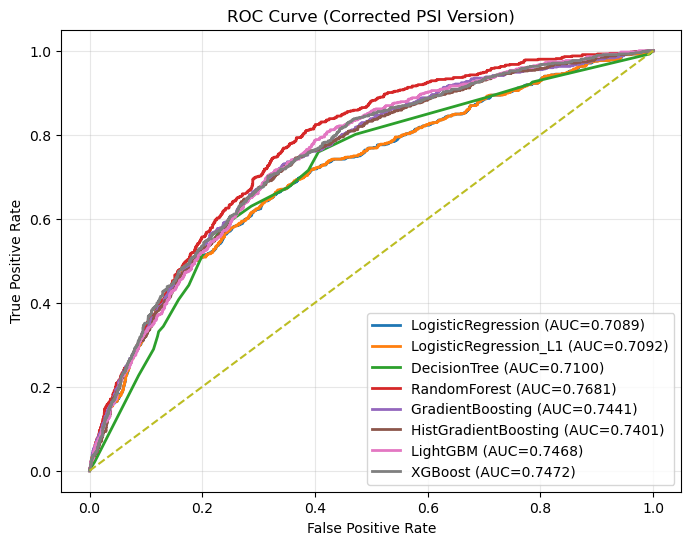

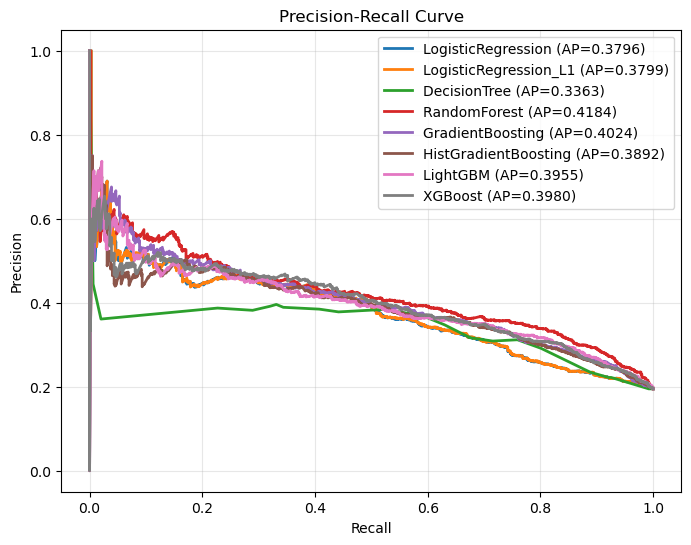

最佳模型： RandomForest
最优阈值： 0.44


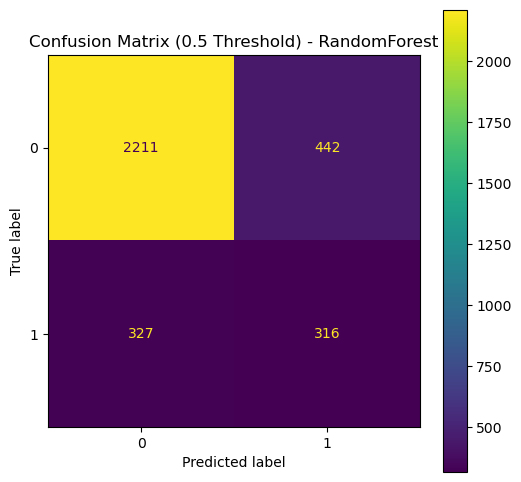

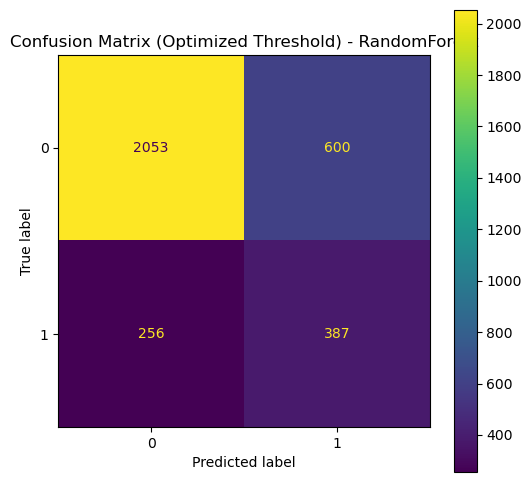

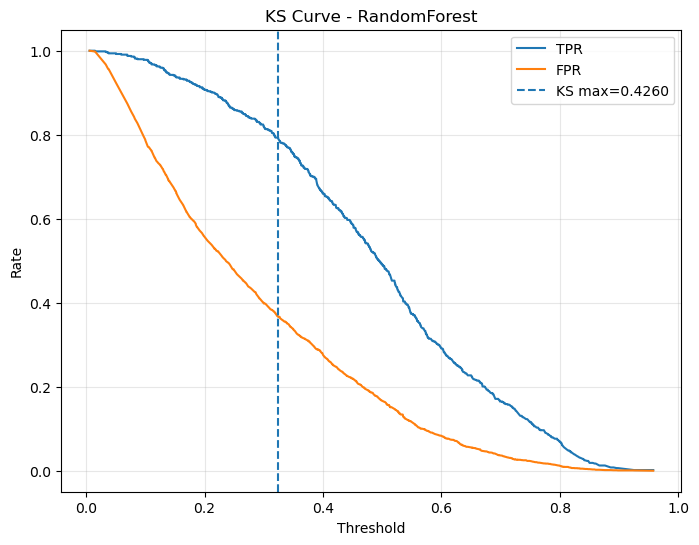

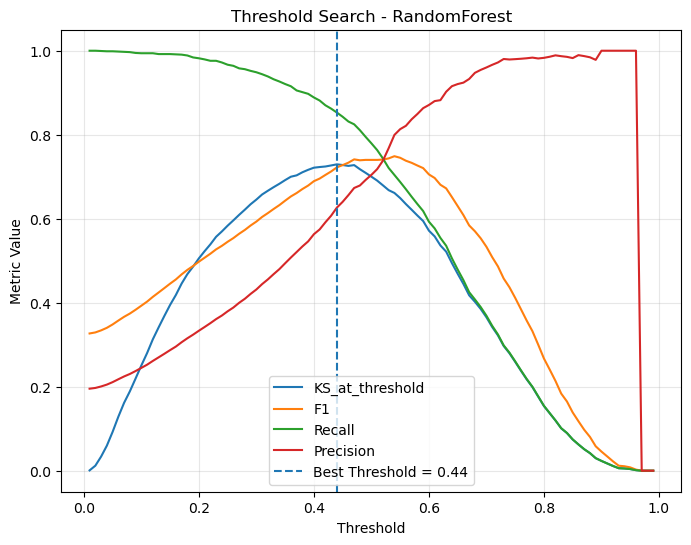

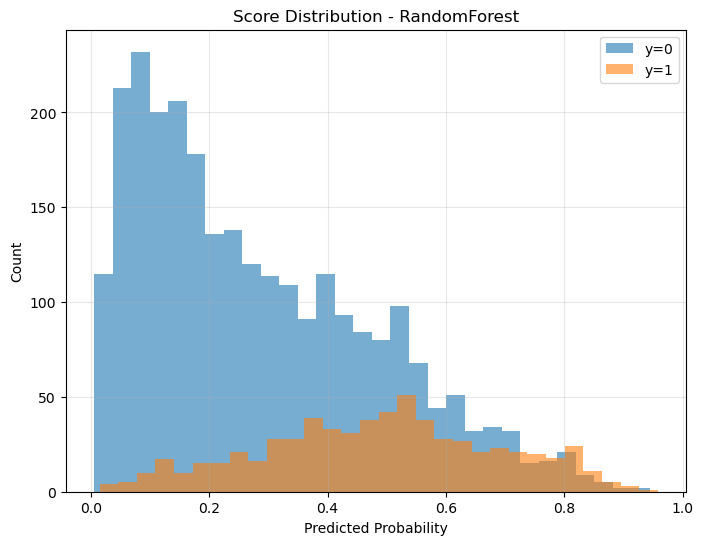

LogisticRegression Feature Importance: 该模型没有 feature_importances_ 属性，跳过。
LogisticRegression_L1 Feature Importance: 该模型没有 feature_importances_ 属性，跳过。


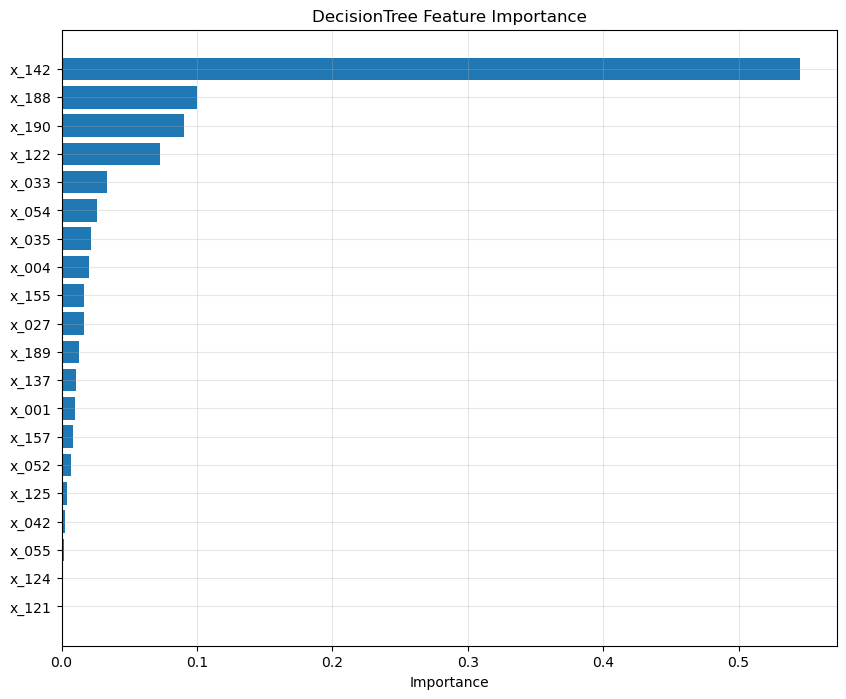

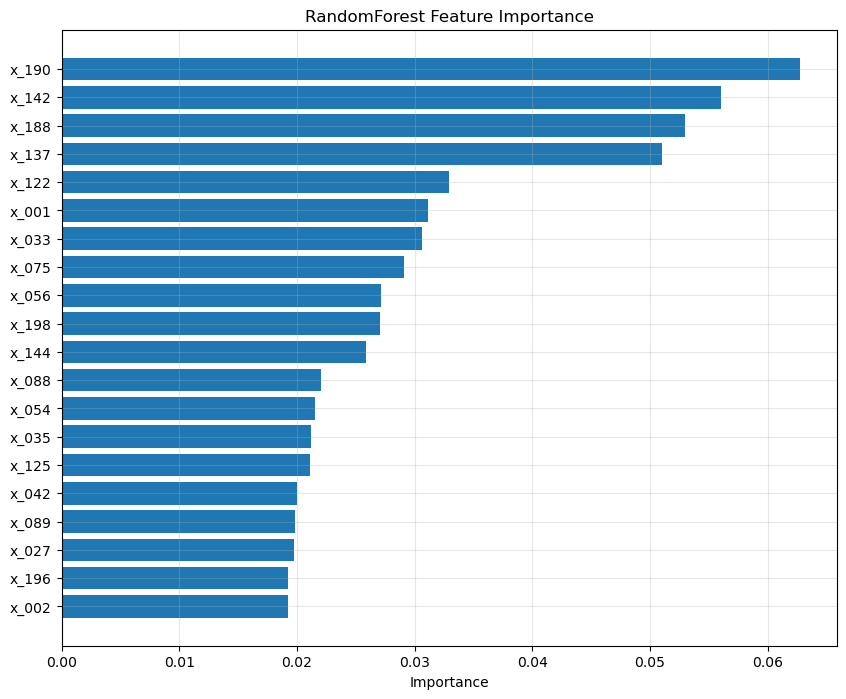

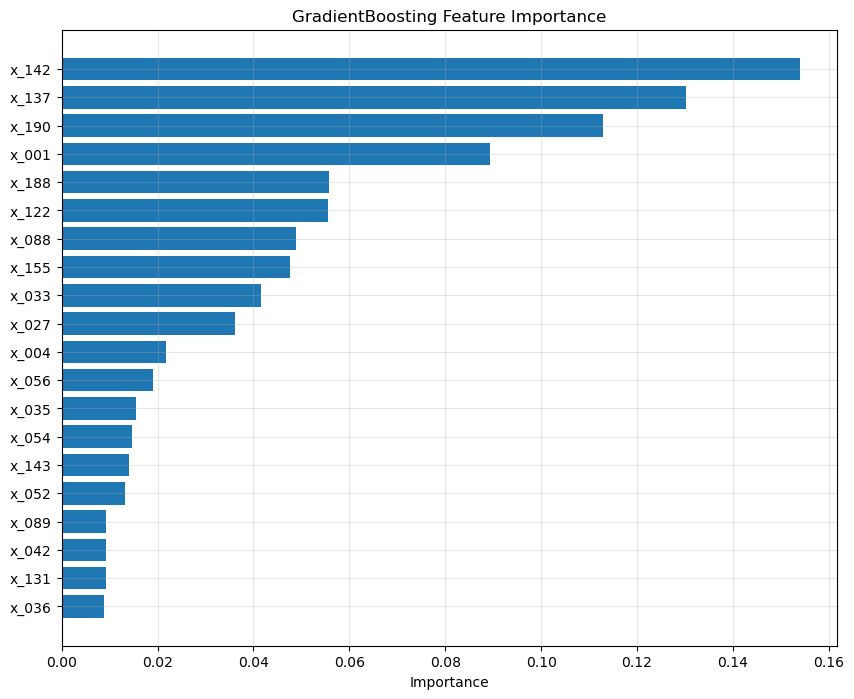

HistGradientBoosting Feature Importance: 该模型没有 feature_importances_ 属性，跳过。


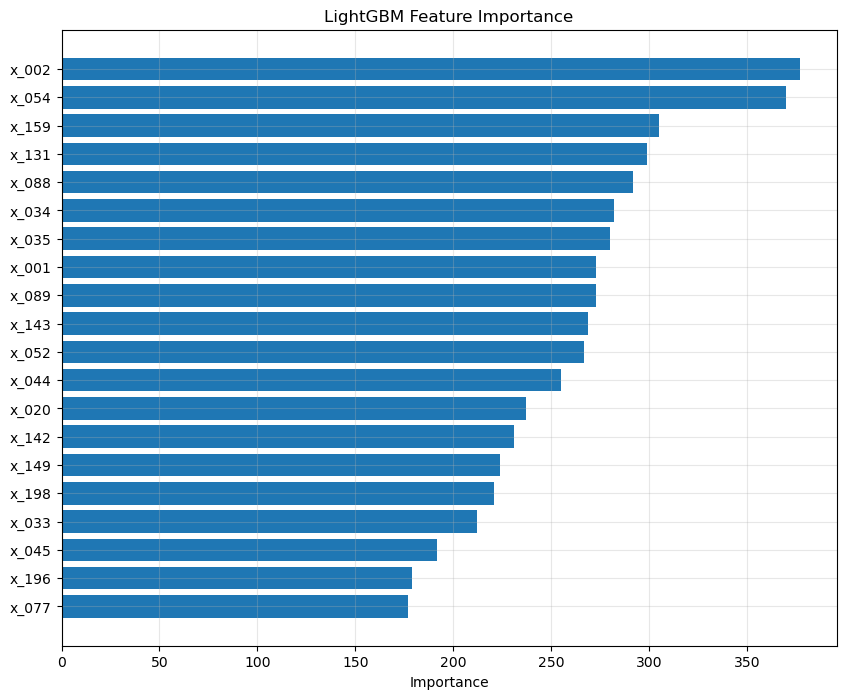

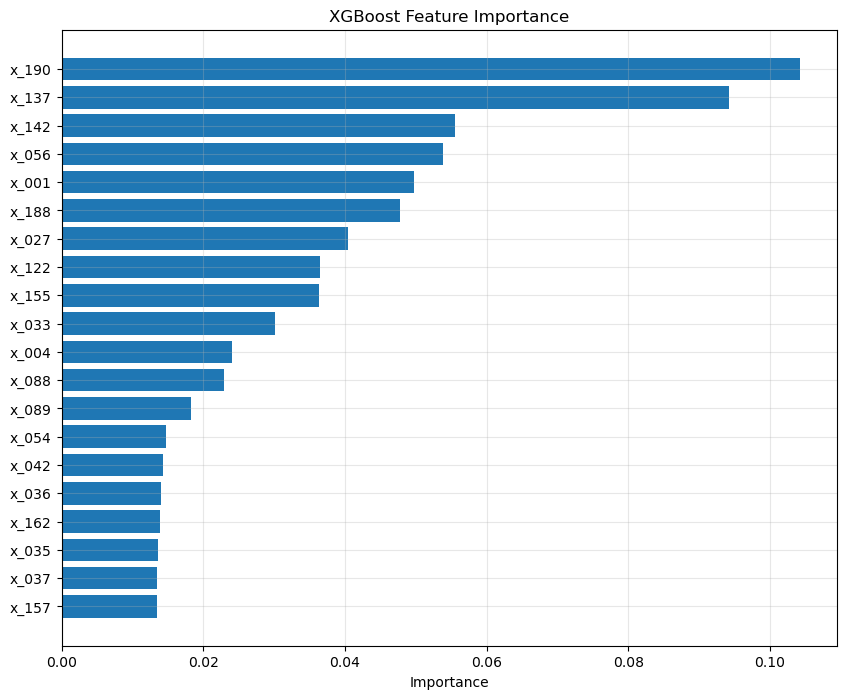

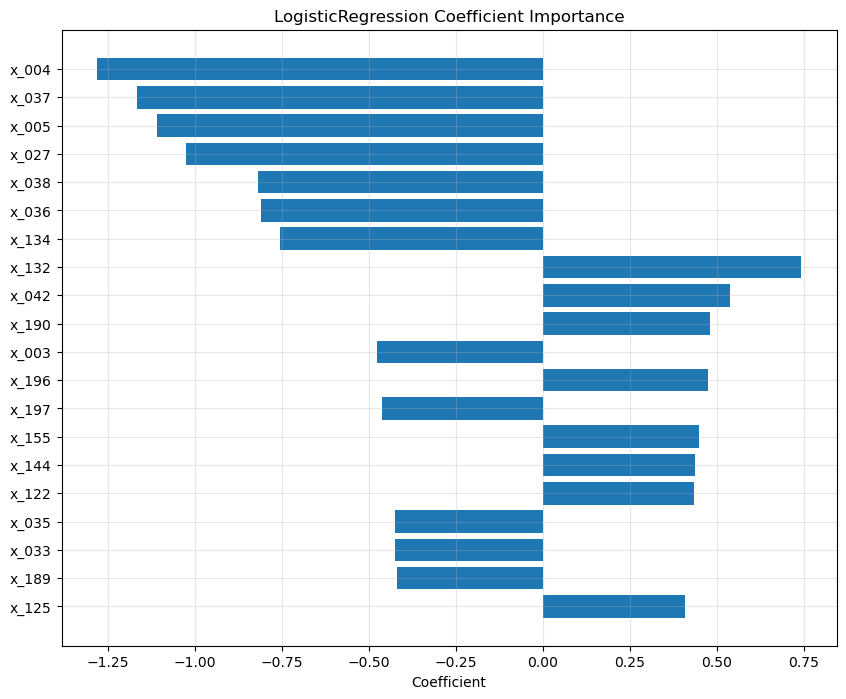

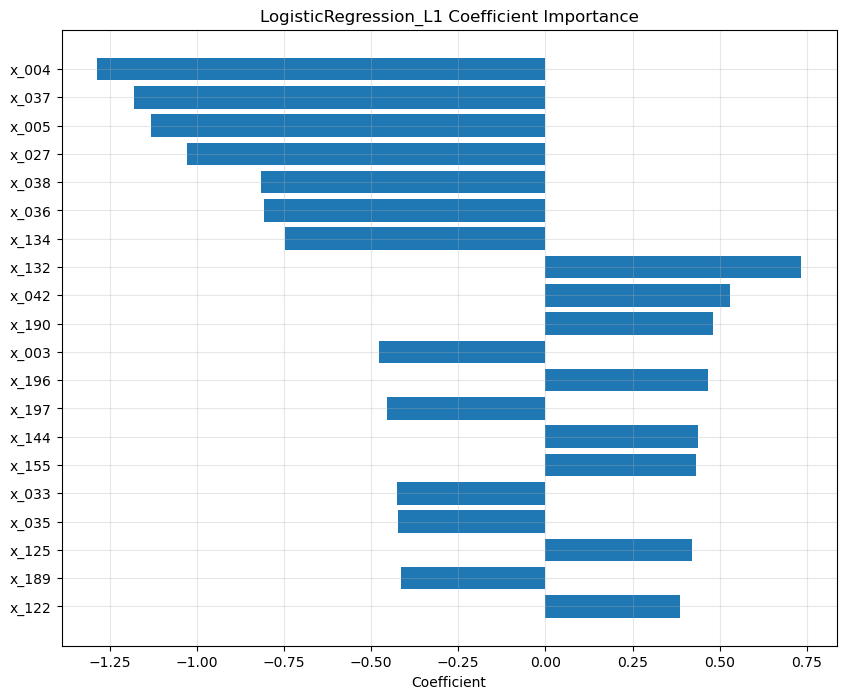

DecisionTree Coefficient Importance: 该模型没有 coef_ 属性，跳过。
RandomForest Coefficient Importance: 该模型没有 coef_ 属性，跳过。
GradientBoosting Coefficient Importance: 该模型没有 coef_ 属性，跳过。
HistGradientBoosting Coefficient Importance: 该模型没有 coef_ 属性，跳过。
LightGBM Coefficient Importance: 该模型没有 coef_ 属性，跳过。
XGBoost Coefficient Importance: 该模型没有 coef_ 属性，跳过。
已保存：best_model_predictions_optimized_threshold.csv


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, precision_recall_curve,
    average_precision_score, confusion_matrix, ConfusionMatrixDisplay
)

# =========================
# 1. 评估基础函数
# =========================
def calculate_ks(y_true, y_score):
    fpr, tpr, thresholds = roc_curve(y_true, y_score)
    ks = np.max(tpr - fpr)
    ks_idx = np.argmax(tpr - fpr)
    return float(ks), fpr, tpr, thresholds, ks_idx

def calculate_psi_corrected(train_scores, test_scores, bins=10):
    train_scores = np.asarray(train_scores, dtype=float)
    test_scores = np.asarray(test_scores, dtype=float)

    train_scores = np.where(np.isfinite(train_scores), train_scores, np.nan)
    test_scores = np.where(np.isfinite(test_scores), test_scores, np.nan)

    train_scores = pd.Series(train_scores).fillna(pd.Series(train_scores).median()).values
    test_scores = pd.Series(test_scores).fillna(pd.Series(train_scores).median()).values

    quantiles = np.linspace(0, 1, bins + 1)
    edges = np.quantile(train_scores, quantiles)
    edges = np.unique(edges)

    if len(edges) < 3:
        return 0.0

    train_bin = pd.cut(train_scores, bins=edges, include_lowest=True)
    test_bin = pd.cut(test_scores, bins=edges, include_lowest=True)

    categories = train_bin.categories
    train_counts = pd.Series(train_bin).value_counts().reindex(categories, fill_value=0).values
    test_counts = pd.Series(test_bin).value_counts().reindex(categories, fill_value=0).values

    train_ratio = (train_counts + 1e-6) / (train_counts.sum() + 1e-6)
    test_ratio = (test_counts + 1e-6) / (test_counts.sum() + 1e-6)

    psi = np.sum((test_ratio - train_ratio) * np.log(test_ratio / train_ratio))
    return float(psi)

def prepare_original_binned_sets(x_train_raw, x_test_raw, bin_edges, reference_df_for_fill):
    x_train_original_binned = apply_binning_edges(x_train_raw.copy(), bin_edges)
    x_test_original_binned = apply_binning_edges(x_test_raw.copy(), bin_edges)

    x_train_original_binned = replace_inf_with_nan(x_train_original_binned)
    x_test_original_binned = replace_inf_with_nan(x_test_original_binned)

    x_train_original_binned = fill_numeric_na(
        x_train_original_binned,
        reference_df=reference_df_for_fill
    )
    x_test_original_binned = fill_numeric_na(
        x_test_original_binned,
        reference_df=reference_df_for_fill
    )

    return x_train_original_binned, x_test_original_binned

def evaluate_model_corrected_psi(model, x_train_original_binned, y_train_original,
                                 x_test_original_binned, y_test_original, model_name):
    train_prob_original = model.predict_proba(x_train_original_binned)[:, 1]
    test_prob_original = model.predict_proba(x_test_original_binned)[:, 1]
    test_pred_default = (test_prob_original >= 0.5).astype(int)

    auc = roc_auc_score(y_test_original, test_prob_original)
    ap = average_precision_score(y_test_original, test_prob_original)
    ks, fpr, tpr, thresholds, ks_idx = calculate_ks(y_test_original, test_prob_original)
    psi = calculate_psi_corrected(train_prob_original, test_prob_original)

    result = {
        "model": model_name,
        "Accuracy": accuracy_score(y_test_original, test_pred_default),
        "Precision": precision_score(y_test_original, test_pred_default, zero_division=0),
        "Recall": recall_score(y_test_original, test_pred_default, zero_division=0),
        "F1": f1_score(y_test_original, test_pred_default, zero_division=0),
        "AUC": auc,
        "AP": ap,
        "KS": ks,
        "PSI": psi
    }

    detail = {
        "train_prob": train_prob_original,
        "test_prob": test_prob_original,
        "test_pred_default": test_pred_default,
        "fpr": fpr,
        "tpr": tpr,
        "thresholds": thresholds,
        "ks_idx": ks_idx
    }

    return result, detail

# =========================
# 2. 阈值搜索函数
# =========================
def threshold_metrics(y_true, y_score, threshold):
    y_true = np.asarray(y_true).astype(int)
    y_score = np.asarray(y_score).astype(float)
    y_pred = (y_score >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    tpr = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0
    ks_at_threshold = tpr - fpr
    tnr = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    balanced_accuracy = 0.5 * (tpr + tnr)

    return {
        "threshold": threshold,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "KS_at_threshold": ks_at_threshold,
        "BalancedAccuracy": balanced_accuracy,
        "TP": tp,
        "FP": fp,
        "TN": tn,
        "FN": fn
    }

def search_best_threshold(y_true, y_score, optimize_metric="ks", threshold_grid=None):
    if threshold_grid is None:
        threshold_grid = np.round(np.linspace(0.01, 0.99, 99), 2)

    records = []
    for thr in threshold_grid:
        records.append(threshold_metrics(y_true, y_score, thr))

    search_df = pd.DataFrame(records)

    metric_map = {
        "ks": "KS_at_threshold",
        "f1": "F1",
        "recall": "Recall",
        "precision": "Precision",
        "balanced_accuracy": "BalancedAccuracy"
    }

    if optimize_metric not in metric_map:
        raise ValueError("optimize_metric 仅支持: ks, f1, recall, precision, balanced_accuracy")

    target_col = metric_map[optimize_metric]
    best_row = search_df.sort_values(by=target_col, ascending=False).iloc[0]

    return best_row, search_df

def plot_feature_importance(model, feature_names, top_n=20, title="Feature Importance"):
    if not hasattr(model, "feature_importances_"):
        print(f"{title}: 该模型没有 feature_importances_ 属性，跳过。")
        return

    importance = pd.DataFrame({
        "feature": feature_names,
        "importance": model.feature_importances_
    }).sort_values("importance", ascending=False).head(top_n)

    plt.figure(figsize=(10, 8))
    plt.barh(importance["feature"][::-1], importance["importance"][::-1])
    plt.xlabel("Importance")
    plt.title(title)
    plt.grid(alpha=0.3)
    plt.show()

def plot_linear_coefficients(model, feature_names, top_n=20, title="Coefficient Importance"):
    if not hasattr(model, "coef_"):
        print(f"{title}: 该模型没有 coef_ 属性，跳过。")
        return

    coef_df = pd.DataFrame({
        "feature": feature_names,
        "coef": model.coef_.ravel()
    })
    coef_df["abs_coef"] = coef_df["coef"].abs()
    coef_df = coef_df.sort_values("abs_coef", ascending=False).head(top_n)

    plt.figure(figsize=(10, 8))
    plt.barh(coef_df["feature"][::-1], coef_df["coef"][::-1])
    plt.xlabel("Coefficient")
    plt.title(title)
    plt.grid(alpha=0.3)
    plt.show()

# =========================
# 3. 重新构造“原始训练集/测试集”的分箱版本
# =========================
x_train_original_binned, x_test_original_binned = prepare_original_binned_sets(
    x_train_raw=x_train,
    x_test_raw=x_test,
    bin_edges=bin_edges,
    reference_df_for_fill=x_train_binned
)

print("x_train_original_binned shape:", x_train_original_binned.shape)
print("x_test_original_binned shape:", x_test_original_binned.shape)

# =========================
# 4. 修正 PSI 后重新评估所有模型
# =========================
results_corrected_psi = []
details_corrected = {}

for name, model in trained_models.items():
    print(f"正在重新评估（修正PSI）: {name}")
    res, detail = evaluate_model_corrected_psi(
        model=model,
        x_train_original_binned=x_train_original_binned,
        y_train_original=y_train,
        x_test_original_binned=x_test_original_binned,
        y_test_original=y_test,
        model_name=name
    )
    results_corrected_psi.append(res)
    details_corrected[name] = detail

results_df_corrected_psi = pd.DataFrame(results_corrected_psi).sort_values(
    by="AUC",
    ascending=False
).reset_index(drop=True)

print("\n修正 PSI 后的模型评估结果：")
display(results_df_corrected_psi)

results_df_corrected_psi.to_csv("metrics_summary_corrected_psi.csv", index=False)
print("已保存：metrics_summary_corrected_psi.csv")

# =========================
# 5. 最优阈值搜索
# 可改成: 'f1' / 'recall' / 'precision' / 'balanced_accuracy'
# =========================
OPTIMIZE_METRIC = "ks"

threshold_summary = []
threshold_search_tables = {}

for model_name in details_corrected.keys():
    train_prob = details_corrected[model_name]["train_prob"]
    test_prob = details_corrected[model_name]["test_prob"]

    best_row, search_df = search_best_threshold(
        y_true=y_train,
        y_score=train_prob,
        optimize_metric=OPTIMIZE_METRIC
    )

    best_threshold = float(best_row["threshold"])
    train_eval = threshold_metrics(y_train, train_prob, best_threshold)
    test_eval = threshold_metrics(y_test, test_prob, best_threshold)

    summary_row = {
        "model": model_name,
        "optimize_metric": OPTIMIZE_METRIC,
        "best_threshold": best_threshold,

        "train_Accuracy": train_eval["Accuracy"],
        "train_Precision": train_eval["Precision"],
        "train_Recall": train_eval["Recall"],
        "train_F1": train_eval["F1"],
        "train_KS_at_threshold": train_eval["KS_at_threshold"],

        "test_Accuracy": test_eval["Accuracy"],
        "test_Precision": test_eval["Precision"],
        "test_Recall": test_eval["Recall"],
        "test_F1": test_eval["F1"],
        "test_KS_at_threshold": test_eval["KS_at_threshold"]
    }

    threshold_summary.append(summary_row)
    threshold_search_tables[model_name] = search_df

threshold_results_df = pd.DataFrame(threshold_summary).sort_values(
    by="test_KS_at_threshold",
    ascending=False
).reset_index(drop=True)

print("\n阈值优化后的结果：")
display(threshold_results_df)

threshold_results_df.to_csv("threshold_optimized_metrics.csv", index=False)
print("已保存：threshold_optimized_metrics.csv")

# =========================
# 6. ROC 曲线
# =========================
plt.figure(figsize=(8, 6))
for name in details_corrected.keys():
    fpr = details_corrected[name]["fpr"]
    tpr = details_corrected[name]["tpr"]
    auc = results_df_corrected_psi.loc[results_df_corrected_psi["model"] == name, "AUC"].values[0]
    plt.plot(fpr, tpr, linewidth=2, label=f"{name} (AUC={auc:.4f})")

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Corrected PSI Version)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# =========================
# 7. PR 曲线
# =========================
plt.figure(figsize=(8, 6))
for name in details_corrected.keys():
    test_prob = details_corrected[name]["test_prob"]
    precision, recall, _ = precision_recall_curve(y_test, test_prob)
    ap = results_df_corrected_psi.loc[results_df_corrected_psi["model"] == name, "AP"].values[0]
    plt.plot(recall, precision, linewidth=2, label=f"{name} (AP={ap:.4f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# =========================
# 8. 选择最佳模型（按修正后AUC最高）
# =========================
best_model_name = results_df_corrected_psi.iloc[0]["model"]
best_model = trained_models[best_model_name]
best_detail = details_corrected[best_model_name]

print("最佳模型：", best_model_name)

best_threshold = float(
    threshold_results_df.loc[
        threshold_results_df["model"] == best_model_name,
        "best_threshold"
    ].values[0]
)
print("最优阈值：", best_threshold)

# =========================
# 9. 最佳模型混淆矩阵（默认阈值0.5）
# =========================
cm_default = confusion_matrix(y_test, best_detail["test_pred_default"])
disp = ConfusionMatrixDisplay(confusion_matrix=cm_default)
fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(ax=ax, values_format="d")
plt.title(f"Confusion Matrix (0.5 Threshold) - {best_model_name}")
plt.show()

# =========================
# 10. 最佳模型混淆矩阵（最优阈值）
# =========================
best_test_prob = best_detail["test_prob"]
best_test_pred_opt = (best_test_prob >= best_threshold).astype(int)

cm_opt = confusion_matrix(y_test, best_test_pred_opt)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_opt)
fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(ax=ax, values_format="d")
plt.title(f"Confusion Matrix (Optimized Threshold) - {best_model_name}")
plt.show()

# =========================
# 11. 最佳模型 KS 曲线
# =========================
thresholds = np.array(best_detail["thresholds"])
fpr = np.array(best_detail["fpr"])
tpr = np.array(best_detail["tpr"])
ks_idx = best_detail["ks_idx"]
ks_value = results_df_corrected_psi.loc[
    results_df_corrected_psi["model"] == best_model_name, "KS"
].values[0]

finite_mask = np.isfinite(thresholds)
thresholds_plot = thresholds[finite_mask]
fpr_plot = fpr[finite_mask]
tpr_plot = tpr[finite_mask]

plt.figure(figsize=(8, 6))
plt.plot(thresholds_plot, tpr_plot, label="TPR")
plt.plot(thresholds_plot, fpr_plot, label="FPR")

if np.isfinite(thresholds[ks_idx]):
    plt.axvline(thresholds[ks_idx], linestyle="--", label=f"KS max={ks_value:.4f}")

plt.xlabel("Threshold")
plt.ylabel("Rate")
plt.title(f"KS Curve - {best_model_name}")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# =========================
# 12. 最优阈值搜索曲线
# =========================
best_search_df = threshold_search_tables[best_model_name]

plt.figure(figsize=(8, 6))
plt.plot(best_search_df["threshold"], best_search_df["KS_at_threshold"], label="KS_at_threshold")
plt.plot(best_search_df["threshold"], best_search_df["F1"], label="F1")
plt.plot(best_search_df["threshold"], best_search_df["Recall"], label="Recall")
plt.plot(best_search_df["threshold"], best_search_df["Precision"], label="Precision")
plt.axvline(best_threshold, linestyle="--", label=f"Best Threshold = {best_threshold:.2f}")
plt.xlabel("Threshold")
plt.ylabel("Metric Value")
plt.title(f"Threshold Search - {best_model_name}")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# =========================
# 13. 最佳模型预测分数分布
# =========================
good_scores = best_detail["test_prob"][np.array(y_test) == 0]
bad_scores = best_detail["test_prob"][np.array(y_test) == 1]

plt.figure(figsize=(8, 6))
plt.hist(good_scores, bins=30, alpha=0.6, label="y=0")
plt.hist(bad_scores, bins=30, alpha=0.6, label="y=1")
plt.xlabel("Predicted Probability")
plt.ylabel("Count")
plt.title(f"Score Distribution - {best_model_name}")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# =========================
# 14. 树模型特征重要性
# =========================
for name, model in trained_models.items():
    plot_feature_importance(
        model,
        x_train_binned.columns,
        top_n=20,
        title=f"{name} Feature Importance"
    )

# =========================
# 15. 线性模型系数图
# =========================
for name, model in trained_models.items():
    plot_linear_coefficients(
        model,
        x_train_binned.columns,
        top_n=20,
        title=f"{name} Coefficient Importance"
    )

# =========================
# 16. 导出最佳模型预测结果
# =========================
best_model_threshold_output = pd.DataFrame({
    "y_true": np.array(y_test),
    "y_prob": best_test_prob,
    "y_pred_default_0.5": (best_test_prob >= 0.5).astype(int),
    "y_pred_optimized": best_test_pred_opt
})

best_model_threshold_output.to_csv("best_model_predictions_optimized_threshold.csv", index=False)
print("已保存：best_model_predictions_optimized_threshold.csv")